# Análisis de tráfico del portal Joomla
Este cuaderno se conecta a PostgreSQL (servicio `database`, puerto 5432) y analiza los logs de Nginx expuestos en `monitoring.v_access_logs`.

**Antes de ejecutar:** navega por `http://localhost/` para generar tráfico.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

url = URL.create(
    "postgresql+psycopg2",
    username=os.environ["POSTGRES_USER"],
    password=os.environ["POSTGRES_PASSWORD"],
    host=os.environ.get("POSTGRES_HOST", "database"),
    port=5432,
    database=os.environ["POSTGRES_DB"],
)
engine = create_engine(url)

with engine.connect() as conn:
    print(conn.execute(text("SELECT version()")).scalar())

PostgreSQL 16.15 on x86_64-pc-linux-musl, compiled by gcc (Alpine 15.2.0) 15.2.0, 64-bit


In [2]:
pd.read_sql("SELECT table_name FROM information_schema.tables WHERE table_schema='public' ORDER BY 1 LIMIT 15", engine)

,table_name
0,joom_action_log_config
1,joom_action_logs
2,joom_action_logs_extensions
3,joom_action_logs_users
4,joom_assets
5,joom_associations
6,joom_banner_clients
7,joom_banner_tracks
8,joom_banners
9,joom_categories


In [3]:
df = pd.read_sql("SELECT * FROM monitoring.v_access_logs ORDER BY ts", engine)
print(f"Total de peticiones registradas: {len(df)}")
df.head(10)

Total de peticiones registradas: 2626


,ts,client_ip,method,uri,status,status_class,bytes_sent,request_time,service
0,2026-10-02 14:46:24+00:00,172.28.1.1,GET,/,502,5xx,559,0.085,joomla
1,2026-10-02 14:46:25+00:00,172.28.1.1,GET,/favicon.ico,502,5xx,559,0.000,joomla
2,2026-10-02 14:46:28+00:00,172.28.1.1,GET,/,502,5xx,559,0.005,joomla
3,2026-10-02 14:46:28+00:00,172.28.1.1,GET,/favicon.ico,502,5xx,559,0.001,joomla
4,2026-10-02 14:46:29+00:00,172.28.1.1,GET,/,502,5xx,559,0.000,joomla
5,2026-10-02 14:46:29+00:00,172.28.1.1,GET,/favicon.ico,502,5xx,559,0.000,joomla
6,2026-10-02 14:46:30+00:00,172.28.1.1,GET,/,502,5xx,559,0.000,joomla
7,2026-10-02 14:46:30+00:00,172.28.1.1,GET,/favicon.ico,502,5xx,559,0.001,joomla
8,2026-10-02 14:46:31+00:00,172.28.1.1,GET,/,502,5xx,559,0.001,joomla
9,2026-10-02 14:46:31+00:00,172.28.1.1,GET,/favicon.ico,502,5xx,559,0.001,joomla


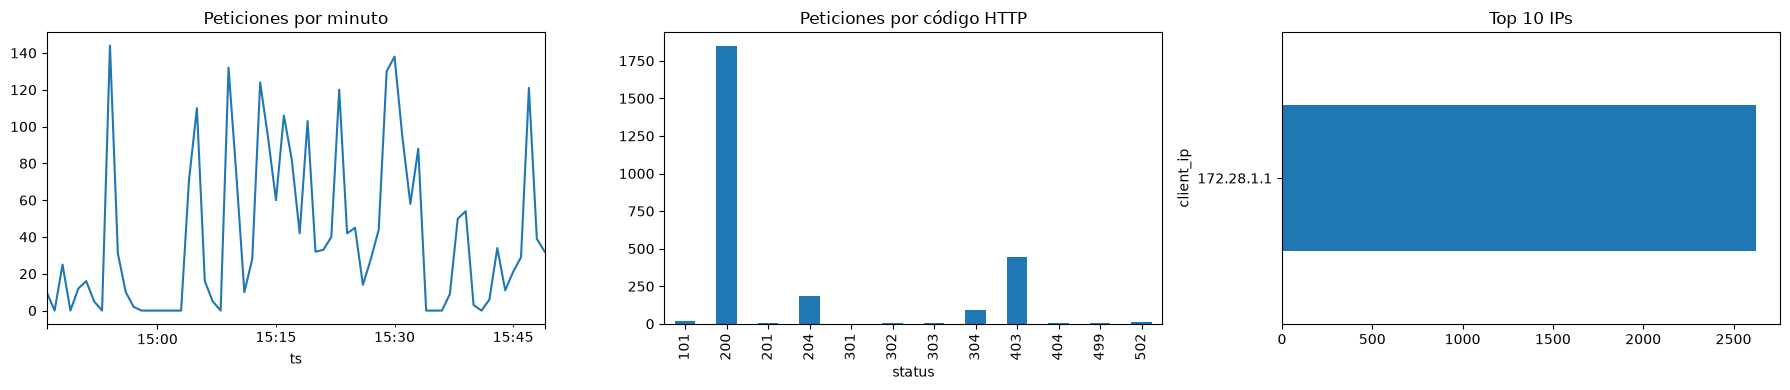

In [4]:
if df.empty:
    print("Sin registros aún: navega por http://localhost/ y vuelve a ejecutar esta celda.")
else:
    fig, ax = plt.subplots(1, 3, figsize=(18, 4))
    df.set_index("ts").resample("1min").size().plot(ax=ax[0], title="Peticiones por minuto")
    df["status"].value_counts().sort_index().plot.bar(ax=ax[1], title="Peticiones por código HTTP")
    df["client_ip"].value_counts().head(10).plot.barh(ax=ax[2], title="Top 10 IPs")
    plt.tight_layout()
    plt.show()